# `local_thickness_imj`
Local-thickness variant that mimics the algorithm used by ImageJ: brute-force sphere insertion, but skipping voxels that are already engulfed by a previously inserted larger sphere. Faster than `local_thickness_bf`.

See the `local_thickness` notebook for a detailed walk-through of the shared concepts; this page focuses on the variant-specific arguments. The wrapper `ps.filters.local_thickness` dispatches to this function when its `method` argument selects this variant.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.local_thickness_imj)

<Signature (im, dt=None, smooth=False, approx=False)>

> Unlike the other `local_thickness_*` variants this function returns a tuple `(lt, count, used)`, where `lt` is the thickness map, `count` is the number of insertions performed, and `used` is a boolean image of the insertion sites. The wrapper `ps.filters.local_thickness(method='imj')` indexes `[0]` so most users never see this.

## `im`
A boolean image with `True` indicating the void phase. Both 2D and 3D images are supported.

spheres inserted: 4768 / 24000 void voxels


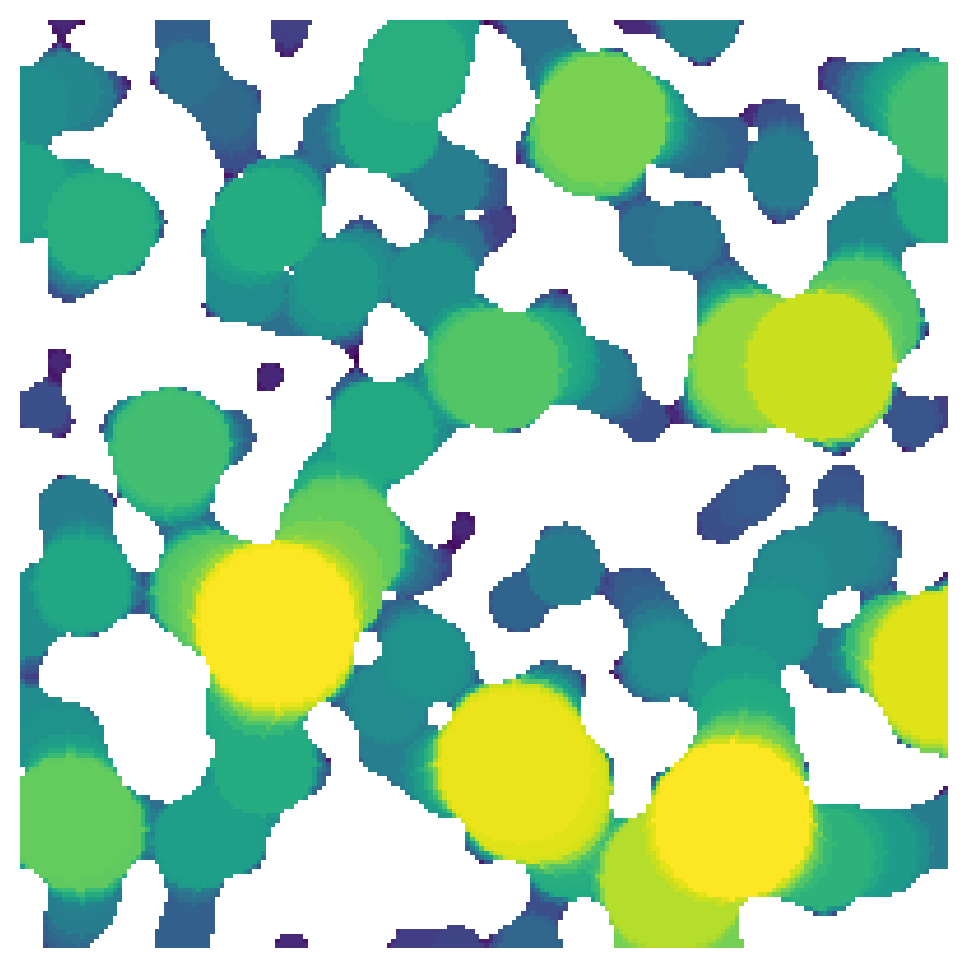

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.6, seed=0)
lt, count, used = ps.filters.local_thickness_imj(im=im)

fig, ax = plt.subplots(figsize=[5, 5])
ax.imshow(lt / im, origin='lower', interpolation='none')
ax.axis(False)
print(f'spheres inserted: {count} / {int(im.sum())} void voxels')

## `dt`
Pre-computed distance transform of the void phase. Saves a small amount of time.

In [4]:
from porespy.tools import get_edt

dt = get_edt()(im)
lt, _, _ = ps.filters.local_thickness_imj(im=im, dt=dt)

## `smooth`
Trims single-voxel protrusions from the inserted spheres.

In [5]:
lt_smooth, _, _ = ps.filters.local_thickness_imj(im=im, smooth=True)
lt_rough, _, _ = ps.filters.local_thickness_imj(im=im, smooth=False)

## `approx`
When `True` the algorithm uses a slightly more aggressive engulfment test that skips more voxels. The result is no longer guaranteed to match the reference implementation voxel-for-voxel, but is much faster on large images.

In [6]:
lt_exact, n_exact, _ = ps.filters.local_thickness_imj(im=im, approx=False)
lt_approx, n_approx, _ = ps.filters.local_thickness_imj(im=im, approx=True)
print(f'exact:  {n_exact} insertions')
print(f'approx: {n_approx} insertions')

exact:  4768 insertions
approx: 1169 insertions
